# HETDEX satellite streaks -- combined paper figures

1. **Spectral properties** -- stacked spectra + Fraunhofer lines (0.75 width) + blue-slope vs. S/N (0.25).
2. **Contamination** -- survey growth + twilight fraction split by epoch (0.5/0.5).

Run top to bottom. Figures saved at 300\,dpi to `figures/`.

In [32]:
import os, warnings, re, datetime
import os.path as op
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from astropy.io import fits
from astropy.table import Table, join
from astropy.time import Time
import astropy.units as u
from astroplan import Observer

warnings.filterwarnings('ignore')

# ---- paths -----------------------------------------------------------------
pdr_dir = '/home/jovyan/Hobby-Eberly-Public/HETDEX/pdr/pdr1/'
if not op.exists(pdr_dir):
    pdr_dir = '/home/jovyan/work/pdr1/'

STREAK_FITS  = 'HETDEX_PDR1_sats.fits'
SUNSET_CACHE = 'sunset_cache_v2.fits'   # local-noon night key (corrected sign)
GCAT_TSV     = 'gcat_satcat.tsv'        # wget -O gcat_satcat.tsv https://planet4589.org/space/gcat/tsv/cat/satcat.tsv
PLOT_DIR     = 'figures'
os.makedirs(PLOT_DIR, exist_ok=True)

# ---- observatory / survey constants ----------------------------------------
HET           = Observer.at_site('HET')
HET_ALT_DEG   = 55.0
UTC_OFFSET_HR = 6.0     # McDonald Observatory UTC-6 (CST, no DST while observing)
G_SPLIT       = 17    # bright/faint split (N=265 each in the paper)

def apjl_style():
    """ApJL rc defaults: serif 8pt, inward ticks, minor ticks on."""
    plt.rcParams.update({
        'font.family':'serif', 'font.size':8, 'axes.labelsize':8, 'axes.titlesize':8,
        'xtick.labelsize':7, 'ytick.labelsize':7,
        'xtick.direction':'in', 'ytick.direction':'in',
        'xtick.top':True, 'ytick.right':True,
        'xtick.minor.visible':True, 'ytick.minor.visible':True,
        'xtick.minor.size':2.0, 'ytick.minor.size':2.0,
        'xtick.major.size':4.0, 'ytick.major.size':4.0,
        'legend.fontsize':6.5, 'legend.framealpha':0.85,
        'lines.linewidth':1.0, 'figure.dpi':200,
    })

apjl_style()
C_ALL, C_BR, C_FN = 'k', '#3A76AF', '#C0392B'
print('pdr_dir:', pdr_dir, '(exists=%s)' % op.exists(pdr_dir))


pdr_dir: /home/jovyan/Hobby-Eberly-Public/HETDEX/pdr/pdr1/ (exists=True)


In [33]:
# ---- streak catalogue + spectra + per-shot metadata ------------------------
idx = Table.read(STREAK_FITS, hdu='INDEX')
with fits.open(STREAK_FITS) as h:
    spectra = h['SPECTRA'].data.astype(float)   # (n_streaks, nwave)
    errors  = h['ERRORS'].data.astype(float)    # (n_streaks, nwave) 1-sigma
n_streaks, nwave = spectra.shape
assert n_streaks == len(idx), 'INDEX / SPECTRA row mismatch!'
WAVE = 3470.0 + np.arange(nwave) * 2.0          # CRVAL3=3470, CDELT3=2
print(f'{n_streaks} streaks | spectra {spectra.shape} | wave {WAVE[0]:.0f}-{WAVE[-1]:.0f} AA')

# full IFU index (one row per IFU per shot); used for denominators + per-shot mjd
ifu_all = Table.read(op.join(pdr_dir, 'ifu-index.fits'))
_meta   = ifu_all['shotid', 'mjd', 'structaz'].group_by('shotid')
shot_meta = _meta.groups.aggregate(np.mean)                     # one row per shot
shot_meta['n_ifu_total'] = ifu_all.group_by('shotid').groups.aggregate(len)['shotid']
print('unique shots in IFU index:', len(shot_meta))

# attach mjd to the streak table via order-preserving dict look-up (do NOT join)
sid2mjd = dict(zip(shot_meta['shotid'].tolist(), shot_meta['mjd'].tolist()))
idx['mjd'] = np.array([sid2mjd.get(int(s), np.nan) for s in idx['shotid']])
print('MJD range:', np.nanmin(idx['mjd']), '-', np.nanmax(idx['mjd']))


533 streaks | spectra (533, 1036) | wave 3470-5540 AA


unique shots in IFU index: 6778
MJD range: 57834.265625 - 60522.166666666664


In [34]:
# ---- spectral stacks + blue index (inputs to the spectral figure) ----------
def band_median(flux, lo, hi):
    m = (WAVE >= lo) & (WAVE <= hi)
    return np.nanmedian(flux[..., m], axis=-1)

norm = band_median(spectra, 4400.0, 4600.0)          # normalise at 4500 A (robust)
good_norm = np.isfinite(norm) & (norm > 0)
fn = spectra / np.where(good_norm, norm, np.nan)[:, None]
en = errors  / np.where(good_norm, norm, np.nan)[:, None]
bad = ~np.isfinite(fn) | ~np.isfinite(en) | (en <= 0)
fn = np.where(bad, np.nan, fn); en = np.where(bad, np.nan, en)

def stack_median(sample):
    f = fn[sample]
    med = np.nanmedian(f, axis=0)
    p16 = np.nanpercentile(f, 16, axis=0)
    p84 = np.nanpercentile(f, 84, axis=0)
    return med, p16, p84

g   = np.asarray(idx['g_mag'], float)
snr = np.asarray(idx['mean_snr'], float)
ok      = good_norm & np.isfinite(g)
bright  = ok & (g <= G_SPLIT)
faint   = ok & (g >  G_SPLIT)
print(f'usable={ok.sum()}  bright={bright.sum()}  faint={faint.sum()}')

med_all, p16_all, p84_all = stack_median(ok)
med_br,  *_ = stack_median(bright)
med_f,   *_ = stack_median(faint)

# per-streak blue index F(3600)/F(4500) for the S/N diagnostic
blue_index = band_median(spectra, 3550.0, 3650.0) / np.where(good_norm, norm, np.nan)

# Fraunhofer reference wavelengths (solar reflected-light features)
LINES = [('Ca II K', 3933.66), ('Ca II H', 3968.47), ('H-delta', 4101.74),
         ('Ca I 4227', 4226.73), ('CH G-band', 4304.0), ('H-gamma', 4340.47),
         ('H-beta', 4861.35), ('Mg b', 5172.70)]


usable=533  bright=401  faint=132


## Figure 1 -- Spectral properties

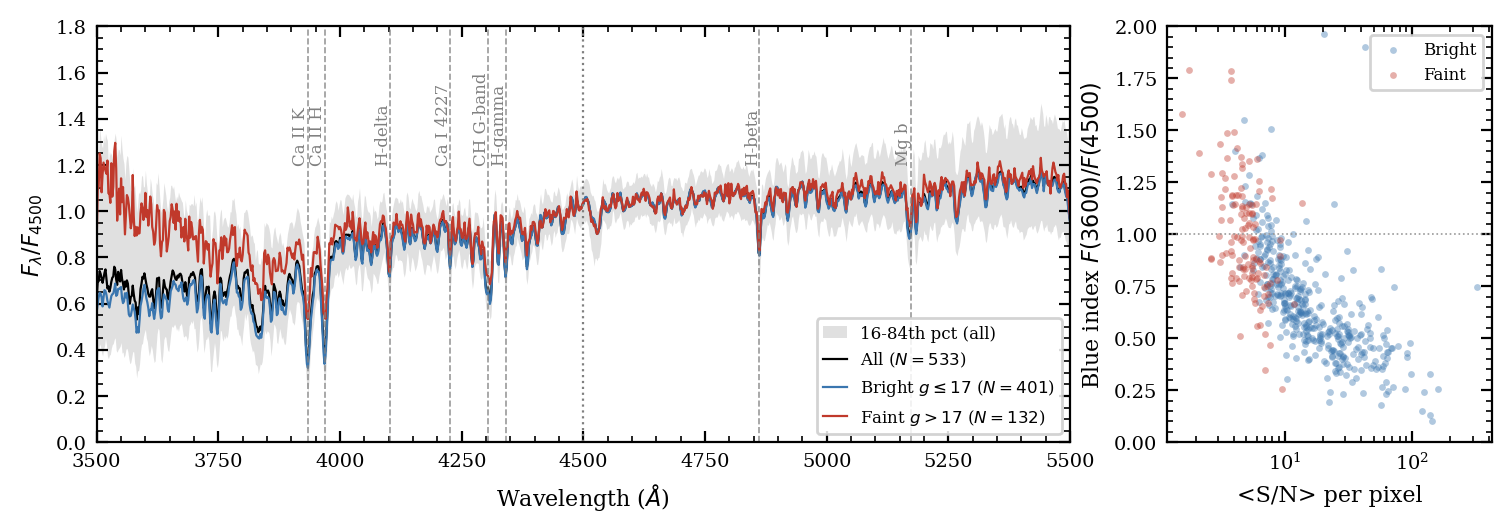

saved spectral_properties.png


In [47]:
# ===== Combined spectral figure: stacked spectra (left) + blue-slope test (right) =====
apjl_style()
fig = plt.figure(figsize=(9, 2.7))
gs  = fig.add_gridspec(1, 2, width_ratios=[3, 1], wspace=0.15)
axS = fig.add_subplot(gs[0, 0])   # stacked spectra
axB = fig.add_subplot(gs[0, 1])   # blue index vs S/N

# ---- left: median stacks with Fraunhofer line markers ----------------------
axS.fill_between(WAVE, p16_all, p84_all, color='0.7', alpha=0.4, lw=0,
                 label='16-84th pct (all)')
axS.plot(WAVE, med_all, color=C_ALL, lw=0.8, label=f'All ($N={int(ok.sum())}$)')
axS.plot(WAVE, med_br,  color=C_BR,  lw=0.8, label=rf'Bright $g\leq{G_SPLIT}$ ($N={int(bright.sum())}$)')
axS.plot(WAVE, med_f,   color=C_FN,  lw=0.8, label=rf'Faint $g>{G_SPLIT}$ ($N={int(faint.sum())}$)')
axS.axvline(4500, color='0.5', ls=':', lw=0.8)
axS.set_xlim(3500, 5500); axS.set_ylim(0.0, 1.8)
axS.set_xlabel(r'Wavelength ($\AA$)'); axS.set_ylabel(r'$F_\lambda / F_{4500}$')
axS.legend(loc='lower right', handlelength=1.4, fontsize=6)
for name, lam in LINES:
    if WAVE[0] < lam < WAVE[-1]:
        axS.axvline(lam, color='grey', ls='--', lw=0.6, alpha=0.8)
        axS.text(lam - 14, 1.2, name, rotation=90, va='bottom', ha='center',
                 fontsize=6, color='grey')


# ---- right: blue index vs S/N (is the faint blue slope S/N-driven?) ---------
axB.scatter(snr[bright], blue_index[bright], s=6, alpha=0.4, lw=0, color=C_BR, label='Bright')
axB.scatter(snr[faint],  blue_index[faint],  s=6, alpha=0.4, lw=0, color=C_FN, label='Faint')
for sel_, c in [(bright, C_BR), (faint, C_FN)]:
    x = snr[sel_]; y = blue_index[sel_]; m = np.isfinite(x) & np.isfinite(y)
    if m.sum() > 10:
        order = np.argsort(x[m]); xs = x[m][order]; ys = y[m][order]
        edges = np.percentile(xs, np.linspace(0, 100, 9))
        cb = 0.5 * (edges[:-1] + edges[1:])
        run = [np.nanmedian(ys[(xs >= edges[i]) & (xs < edges[i+1])]) for i in range(len(edges)-1)]
        #axB.plot(cb, run, color=c, lw=1.3)
axB.axhline(1.0, color='0.6', lw=0.6, ls=':')
axB.set_xscale('log'); axB.set_ylim(0, 2.0)
axB.set_xlabel('<S/N> per pixel'); axB.set_ylabel(r'Blue index $F(3600)/F(4500)$')
axB.legend(loc='upper right', fontsize=6)

fig.savefig(f'{PLOT_DIR}/spectral_properties.png', dpi=300, bbox_inches='tight')
plt.show()
print('saved spectral_properties.png')


## Figure 2 -- Contamination

In [36]:
# ---- twilight contamination RATE vs hours after astronomical twilight ------
all_mjd = np.asarray(shot_meta['mjd'], float)
all_sid = np.asarray(shot_meta['shotid'])

def night_key(mjd):
    # roll over at LOCAL NOON (McDonald, UTC-6): floor(mjd - 0.5 - 6/24)
    return np.floor(mjd - 0.5 - UTC_OFFSET_HR / 24.0).astype('int64')

nk_all = night_key(all_mjd)
uniq_nights = np.unique(nk_all[np.isfinite(all_mjd)])
print('unique observing nights:', len(uniq_nights))

if op.exists(SUNSET_CACHE):
    cache = Table.read(SUNSET_CACHE)
    print('loaded', SUNSET_CACHE, '(%d nights)' % len(cache))
else:
    from tqdm import tqdm
    rows = []
    for nk in tqdm(uniq_nights, desc='sunset/twilight'):
        t_noon = Time(float(nk) + 0.5 + UTC_OFFSET_HR / 24.0, format='mjd', scale='utc')
        twi = HET.sun_set_time(t_noon, which='next', horizon=-18 * u.deg)
        rows.append({'night_key': int(nk), 'twilight_mjd': float(twi.mjd)})
    cache = Table(rows); cache.sort('night_key')
    cache.write(SUNSET_CACHE, overwrite=True)
    print('wrote', SUNSET_CACHE, '(%d nights)' % len(cache))

nk2twi = dict(zip(cache['night_key'].tolist(), cache['twilight_mjd'].tolist()))
dt_twi_all = (all_mjd - np.array([nk2twi.get(int(k), np.nan) for k in nk_all])) * 24.0
finite = np.isfinite(dt_twi_all)
print(f'dt_twilight range: {np.nanmin(dt_twi_all):.2f} - {np.nanmax(dt_twi_all):.2f} hr')

# contaminated shots = shotids present in the streak INDEX
sat_sids = set(int(s) for s in idx['shotid'])
is_sat   = np.array([int(s) in sat_sids for s in all_sid])

bins  = np.arange(-0.5, 9.51, 1.0)
tctr  = 0.5 * (bins[:-1] + bins[1:])
n_tot, _ = np.histogram(dt_twi_all[finite], bins=bins)
n_sat, _ = np.histogram(dt_twi_all[finite & is_sat], bins=bins)
tfrac = n_sat / np.maximum(n_tot, 1)
tferr = np.sqrt(np.maximum(tfrac * (1 - tfrac), 0) / np.maximum(n_tot, 1))   # binomial
print(f'contaminated shots: {is_sat.sum()}/{len(all_sid)} = {is_sat.mean()*100:.2f}%')

# ---- contamination as a trend of time: same twilight axis, split by epoch --
yr_all = np.array([t.year for t in Time(all_mjd, format='mjd').to_datetime()])
EPOCHS = [('2017-2020', 2017, 2020), ('2021-2022', 2021, 2022), ('2023-2024', 2023, 2024)]

def rate_twi_epoch(ymask):
    m = finite & ymask
    nt, _ = np.histogram(dt_twi_all[m], bins=bins)
    ns, _ = np.histogram(dt_twi_all[m & is_sat], bins=bins)
    fr = ns / np.maximum(nt, 1)
    fe = np.sqrt(np.maximum(fr * (1 - fr), 0) / np.maximum(nt, 1))   # binomial
    return fr * 100, fe * 100, nt

for lab, y0, y1 in EPOCHS:
    print(f'  epoch {lab}: {np.sum(finite & (yr_all>=y0) & (yr_all<=y1))} shots, '
          f'{np.sum(finite & (yr_all>=y0) & (yr_all<=y1) & is_sat)} contaminated')


unique observing nights: 1273
loaded sunset_cache_v2.fits (1273 nights)
dt_twilight range: -0.51 - 10.60 hr
contaminated shots: 497/6778 = 7.33%
  epoch 2017-2020: 3430 shots, 130 contaminated
  epoch 2021-2022: 2086 shots, 209 contaminated
  epoch 2023-2024: 1262 shots, 158 contaminated


In [37]:
# ---- monthly contamination fraction (denominator = good shots) -------------
if 'response_4540' in ifu_all.colnames:
    ifu_good = ifu_all[ifu_all['response_4540'] > 0.08]
else:
    ifu_good = ifu_all
    print('WARNING: response_4540 not found - no throughput cut applied')
_, uix = np.unique(ifu_good['shotid'], return_index=True)
shots_uniq = ifu_good[uix]                       # one row per good shot
print('unique good shots (denominator):', len(shots_uniq))

def shotid_to_month(a):                          # shotid YYYYMMDDXXX -> YYYYMM
    return np.array([int(str(int(s))[:6]) for s in a])

shots_months  = shotid_to_month(shots_uniq['shotid'])
months_sorted = np.unique(shots_months)

streaks_per_shot = {}
for sid in idx['shotid']:
    streaks_per_shot[int(sid)] = streaks_per_shot.get(int(sid), 0) + 1
sat_shotids = np.array([s for s, n in streaks_per_shot.items() if n >= 1])
sat_shotids = sat_shotids[np.isin(sat_shotids, shots_uniq['shotid'])]
sat_months  = shotid_to_month(sat_shotids)

n_total_monthly  = np.array([np.sum(shots_months == m) for m in months_sorted])
n_streak_monthly = np.array([np.sum(sat_months   == m) for m in months_sorted])
fraction_monthly = n_streak_monthly / np.maximum(n_total_monthly, 1)

# bi-monthly smoothing
monthbin = 2
bimonth_centres, fraction_bimonth = [], []
for i in np.arange(0, len(months_sorted), monthbin):
    if i < len(months_sorted) - monthbin:
        sm = (shots_months >= months_sorted[i]) & (shots_months < months_sorted[i + monthbin])
        ss = (sat_months   >= months_sorted[i]) & (sat_months   < months_sorted[i + monthbin])
    else:
        sm = shots_months >= months_sorted[-1]; ss = sat_months >= months_sorted[-1]
    bimonth_centres.append(months_sorted[i])
    fraction_bimonth.append(np.sum(ss) / max(np.sum(sm), 1))
bimonth_centres = np.array(bimonth_centres); fraction_bimonth = np.array(fraction_bimonth)

def ym_to_dt(a):
    return np.array([datetime.datetime.strptime(str(int(m)), '%Y%m') for m in a])
month_dt   = ym_to_dt(months_sorted)
bimonth_dt = ym_to_dt(bimonth_centres)
print(f'overall fraction: {len(sat_shotids)/len(shots_uniq)*100:.2f}%  '
      f'peak monthly: {fraction_monthly.max()*100:.1f}% ({months_sorted[np.argmax(fraction_monthly)]})')


unique good shots (denominator): 6778
overall fraction: 7.33%  peak monthly: 22.7% (202307)


In [38]:
# ---- active payloads in orbit from GCAT (McDowell, planet4589.org) ---------
# One-time download:
#   wget -O gcat_satcat.tsv https://planet4589.org/space/gcat/tsv/cat/satcat.tsv
if not op.exists(GCAT_TSV):
    gcat_available = False
    print(f'{GCAT_TSV} not found - payload curves will be skipped. Download with:')
    print('  wget -O gcat_satcat.tsv https://planet4589.org/space/gcat/tsv/cat/satcat.tsv')
else:
    gcat_available = True
    with open(GCAT_TSV, 'r', encoding='utf-8', errors='replace') as f:
        raw = f.readlines()
    header_line = next(i for i, l in enumerate(raw) if l.startswith('#') and '\t' in l)
    cols = [c.strip() for c in raw[header_line].lstrip('#').rstrip('\n').split('\t')]
    comment_rows = [i for i, l in enumerate(raw) if l.startswith('#') and i != header_line]
    gcat = pd.read_csv(GCAT_TSV, sep='\t', header=None, names=cols,
                       skiprows=comment_rows + [header_line], low_memory=False,
                       na_values=['-', ''], on_bad_lines='skip')
    print(f'GCAT: {len(gcat)} rows')

    def parse_gcat_date(s):
        if pd.isna(s):
            return pd.NaT
        s = re.sub(r'\s+\d{4}\??\s*$', '', str(s).strip())
        s = re.sub(r'[?~]', '', s).strip(); s = re.sub(r'\s+', ' ', s)
        for fmt in ('%Y %b %d', '%Y %b'):
            try:
                return pd.to_datetime(s, format=fmt)
            except ValueError:
                continue
        try:
            return pd.to_datetime(s)
        except Exception:
            return pd.NaT

    gcat['launch_dt'] = gcat['LDate'].apply(parse_gcat_date)
    gcat['decay_dt']  = gcat['DDate'].apply(parse_gcat_date)
    payloads  = gcat[gcat['Type'].astype(str).str.startswith('P')].copy()
    name_col  = 'PLName' if 'PLName' in payloads.columns else 'Name'
    starlinks = payloads[payloads[name_col].astype(str).str.contains('STARLINK', case=False, na=False)]
    print(f'payloads: {len(payloads)}   Starlink: {len(starlinks)}')

    t_min = Time(np.nanmin(shots_uniq['mjd']), format='mjd').to_datetime()
    t_max = Time(np.nanmax(shots_uniq['mjd']), format='mjd').to_datetime()
    survey_months = pd.date_range(f'{t_min.year}-{t_min.month:02d}-01',
                                  f'{t_max.year}-{t_max.month:02d}-01', freq='MS')
    rows = []
    for m0 in survey_months:
        m1 = m0 + pd.offsets.MonthEnd(1)
        def n_active(df):
            up = df['decay_dt'].isna() | (df['decay_dt'] >= m0)
            return int(((df['launch_dt'] <= m1) & up).sum())
        rows.append({'month_dt': m0.to_pydatetime(),
                     'n_active': n_active(payloads), 'n_starlink': n_active(starlinks)})
    sat_counts = pd.DataFrame(rows)
    print(sat_counts.tail(3).to_string(index=False))


GCAT: 69999 rows


payloads: 27853   Starlink: 12446
  month_dt  n_active  n_starlink
2024-05-01     13143        6118
2024-06-01     13253        6246
2024-07-01     13286        6307


In [39]:
#! wget -O gcat_satcat.tsv https://planet4589.org/space/gcat/tsv/cat/satcat.tsv

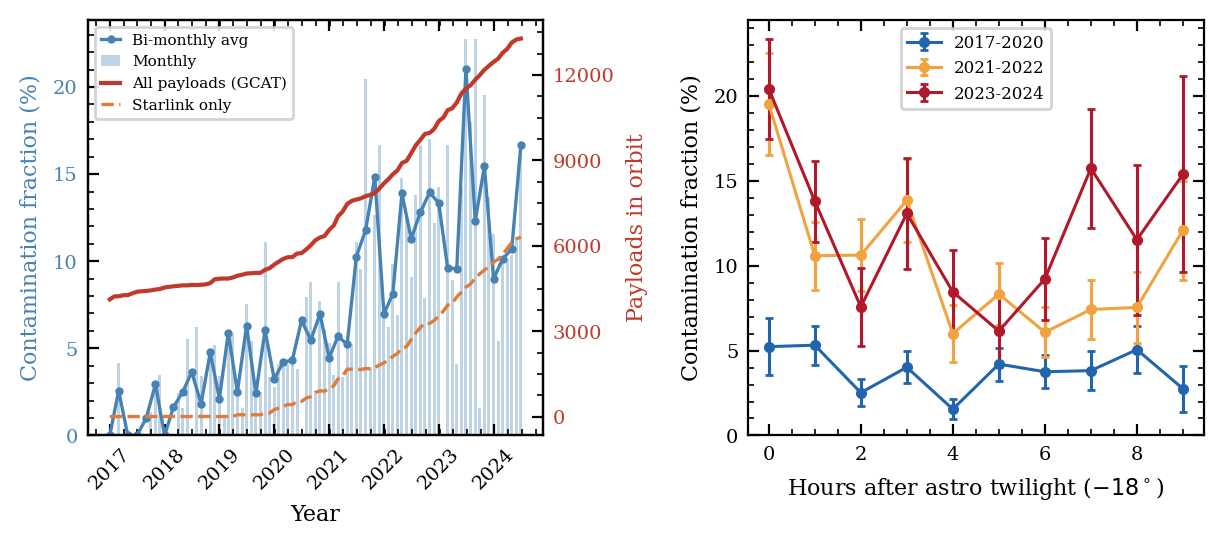

saved contamination.png


In [40]:
# ===== Combined contamination figure: growth (left) + twilight by epoch (right) =====
apjl_style()
fig = plt.figure(figsize=(7.2, 2.7))
gs  = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.45)
axT = fig.add_subplot(gs[0, 0])   # growth over the survey
axW = fig.add_subplot(gs[0, 1])   # twilight dependence, split by survey epoch

# ---- left: monthly/bi-monthly fraction + payloads in orbit -----------------
ax2 = axT.twinx()
axT.bar(month_dt, fraction_monthly * 100, width=20, color='steelblue', alpha=0.35,
        lw=0, label='Monthly')
axT.plot(bimonth_dt, fraction_bimonth * 100, 'o-', color='steelblue', ms=2, lw=1.2,
         label='Bi-monthly avg')
axT.set_ylabel('Contamination fraction (%)', color='steelblue')
axT.tick_params(axis='y', labelcolor='steelblue')
axT.set_ylim(0, None)
if gcat_available:
    ax2.plot(sat_counts['month_dt'], sat_counts['n_active'], '-', color='#C0392B',
             lw=1.5, label='All payloads (GCAT)')
    ax2.plot(sat_counts['month_dt'], sat_counts['n_starlink'], '--', color='#E07B39',
             lw=1.2, label='Starlink only')
ax2.set_ylabel('Payloads in orbit', color='#C0392B')
ax2.tick_params(axis='y', labelcolor='#C0392B')
ax2.yaxis.set_major_locator(plt.MaxNLocator(5, integer=True))
axT.set_xlabel('Year')
axT.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axT.xaxis.set_major_locator(mdates.YearLocator())
axT.tick_params(axis='x', rotation=45)
h1, l1 = axT.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
axT.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=5.5, handlelength=1.2)

# ---- right: contamination fraction vs hours after twilight, by survey epoch -
epoch_cols = ['#2166AC', '#F1A340', '#B2182B']   # cool -> hot = early -> recent
for (lab, y0, y1), col in zip(EPOCHS, epoch_cols):
    fr, fe, nt = rate_twi_epoch((yr_all >= y0) & (yr_all <= y1))
    good = nt >= 5
    axW.errorbar(tctr[good], fr[good], yerr=fe[good], fmt='o-', color=col, ms=3,
                 lw=1.1, capsize=1.5, label=lab)
axW.set_xlabel(r'Hours after astro twilight ($-18^\circ$)')
axW.set_ylabel('Contamination fraction (%)')
axW.set_ylim(0, None)
axW.legend(fontsize=6, title_fontsize=6)

fig.savefig(f'{PLOT_DIR}/contamination.png', dpi=300, bbox_inches='tight')
plt.show()
print('saved contamination.png')


In [41]:
def twi_numbers(ymask, beyond_hr=1.5):
    m = finite & ymask
    pk = m & (dt_twi_all < 0.5)          # first bin, 0-1 h after twilight
    by = m & (dt_twi_all >= beyond_hr)   # beyond twilight
    peak   = 100*np.mean(is_sat[pk]) if pk.sum() else np.nan
    beyond = 100*np.mean(is_sat[by]) if by.sum() else np.nan
    return peak, beyond, int(pk.sum()), int(by.sum())

print(f'{"sample":12s}{"peak(0-1h)":>12s}{"beyond(>1.5h)":>15s}{"Npeak":>8s}{"Nbeyond":>9s}')
p,b,n1,n2 = twi_numbers(np.ones_like(finite))
print(f'{"ALL":12s}{p:>11.1f}%{b:>14.1f}%{n1:>8d}{n2:>9d}')
for lab,y0,y1 in EPOCHS:
    p,b,n1,n2 = twi_numbers((yr_all>=y0)&(yr_all<=y1))
    print(f'{lab:12s}{p:>11.1f}%{b:>14.1f}%{n1:>8d}{n2:>9d}')

sample        peak(0-1h)  beyond(>1.5h)   Npeak  Nbeyond
ALL                15.2%           6.3%     533     5423
2017-2020           5.2%           3.5%     173     2881
2021-2022          19.5%           8.9%     174     1676
2023-2024          20.4%          10.5%     186      866


In [42]:
edges = bins
def bin_report(lab, ymask):
    m = finite & ymask
    nt, _ = np.histogram(dt_twi_all[m], bins=edges)
    ns, _ = np.histogram(dt_twi_all[m & is_sat], bins=edges)
    lo = int(np.sum(m & (dt_twi_all <  edges[0])))
    hi = int(np.sum(m & (dt_twi_all >= edges[-1])))
    print(f'\n{lab}:  outside range -> dt<{edges[0]:.1f}: {lo} shots,  dt>={edges[-1]:.1f}: {hi} shots')
    print(f'  {"bin(h)":>6s}{"Nshots":>8s}{"Nsat":>6s}{"frac%":>7s}   plotted?')
    for c, n, s in zip(tctr, nt, ns):
        print(f'  {c:>6.0f}{n:>8d}{s:>6d}{100*s/max(n,1):>7.1f}   {"yes" if n>=5 else "HIDDEN (<5)"}')

bin_report('ALL', np.ones_like(finite))
for lab, y0, y1 in EPOCHS:
    bin_report(lab, (yr_all>=y0) & (yr_all<=y1))


ALL:  outside range -> dt<-0.5: 1 shots,  dt>=9.5: 209 shots
  bin(h)  Nshots  Nsat  frac%   plotted?
       0     532    81   15.2   yes
       1     822    74    9.0   yes
       2     736    42    5.7   yes
       3     732    59    8.1   yes
       4     782    30    3.8   yes
       5     786    45    5.7   yes
       6     777    43    5.5   yes
       7     625    45    7.2   yes
       8     468    31    6.6   yes
       9     308    25    8.1   yes

2017-2020:  outside range -> dt<-0.5: 1 shots,  dt>=9.5: 118 shots
  bin(h)  Nshots  Nsat  frac%   plotted?
       0     172     9    5.2   yes
       1     376    20    5.3   yes
       2     397    10    2.5   yes
       3     423    17    4.0   yes
       4     452     7    1.5   yes
       5     428    18    4.2   yes
       6     373    14    3.8   yes
       7     288    11    3.8   yes
       8     257    13    5.1   yes
       9     145     4    2.8   yes

2021-2022:  outside range -> dt<-0.5: 0 shots,  dt>=9.5: 64 shots
 